In [60]:
from typing import Dict, TypedDict, List
from langgraph.graph import StateGraph, END
import random

In [61]:
class AgentState(TypedDict):
    player_name: str
    target_number: int
    guesses: List[int]
    attempts: int
    lower_bound: int
    upper_bound: int

In [62]:
def setup_node(state: AgentState) -> AgentState:
    """This node setups up the variables for guessing game and greets player"""
    state["player_name"] = f"Hi {state['player_name']}"
    state["target_number"] = random.randint(1, 20)
    state["lower_bound"] = 1 
    state["upper_bound"] = 20 
    guesses = []
    state["attempts"] = 0
    return state

In [63]:
def guess_node(state: AgentState) -> AgentState:
    """This node generates a guess between the upper and lower bound and appends it to guesses"""
    guess = random.randint(state["lower_bound"], state["upper_bound"])
    
    state["guesses"].append(guess)
    state["attempts"] += 1
    
    if guess < state["target_number"]:
        state["lower_bound"] = guess + 1
    elif guess > state["target_number"]:
        state["upper_bound"] = guess - 1
        
    return state

In [64]:
def should_continue(state: AgentState) -> AgentState:
    """This function determines whether or not to loop"""
    latest_guess = state["guesses"][-1]
    if state["target_number"] == latest_guess:
        print("FOUND NUMBER", state["attempts"])
        return "exit"
    elif state["attempts"] < 7:
        print("START LOOP", state["attempts"])
        return "loop"
    else: 
        return "exit"

In [65]:
graph = StateGraph(AgentState)

graph.add_node("setup",setup_node)
graph.add_node("guess", guess_node)

graph.set_entry_point("setup")
graph.add_edge("setup","guess")
graph.add_conditional_edges(
    "guess",
    should_continue,
    {
        "loop": "guess",
        "exit": END
    }
)

app = graph.compile()

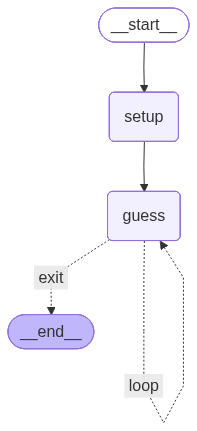

In [66]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [69]:
app.invoke({"player_name":"Sam","target_number":100,"guesses":[],"attemps":-100,"lower_bound":100,"upper_bound":-100})

START LOOP 1
START LOOP 2
START LOOP 3
START LOOP 4
FOUND NUMBER 5


{'player_name': 'Hi Sam',
 'target_number': 3,
 'guesses': [10, 7, 2, 6, 3],
 'attempts': 5,
 'lower_bound': 3,
 'upper_bound': 5}